<a href="https://colab.research.google.com/github/LaviniBastos/Burnout-system/blob/main/EDA_geral_DadosCAT_INSS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise Exploratória da Base - Comunicação de Acidente de Trabalho (CAT/INSS).

### Projeto: Análise e Modelagem Preditiva de Afastamentos por Burnout / Transtornos Mentais

- Etapa: Análise exploratória em busca de insights
- Status: Concluído.


### Visão Geral e Objetivos

O objetivo principal desta etapa é transformar os dados que temos em respostas para as nossas perguntas a respeito das principais caracteristicas e fatores que levam à sindrome de burnout. Mas antes precisamos fazer uma verificação macro para entender um pouco mais os perfis demográficos, setores mais afetados, localização e etc:

- **Perfil Demográfico:** Distribuição por **Gênero** e **Faixa Etária** dos trabalhadores com afastamento por Burnout.

- **Geografia do Esgotamento:** Mapeamento por **UF/Município** de maior incidência.

- **Setores Econômicos mais Afetados (CNAE):** Descobrir quais ramos de atividade concentram a maioria dos registros de CAT por Burnout.

- **Tendência Temporal:** Gráficos de linha mostrando se os registros de CAT por causas mentais estão subindo mês a mês.

- **Tipo de Acidente/Afastamento:** Verificar o tempo de afastamento e o impacto previdenciário.

Fonte dos dados brutos:
- https://dados.gov.br/dados/organizacoes/visualizar/instituto-nacional-do-seguro-social

- https://dados.gov.br/dados/conjuntos-dados/comunicacoes-de-acidente-de-trabalho-cat-plano-de-dados-abertos-jun-2023-a-jun-2025

Base tratada sendo usada nessa análise:
- https://colab.research.google.com/drive/1YfXCLIA7GY8Q7CMfUl4QYqRTjj--9iTM#scrollTo=CAhNSJdCDFUs


In [ ]:
## Libs necessárias importadas
import pandas as pd
import numpy as np

In [ ]:
# importanto parquet dos dados tratados
df = pd.read_parquet('/content/df_geral_tratado.parquet')
df.shape

(1735647, 24)

---

### Correções na base antes da análise


A prof Andressa no relatório do dia 19/08 pediu umas alterações na base:
Há uma suspeita que a base tenha sofrido uma compactação incorreta  no campo `uf_empregador` que embaralhou algumas siglas de estado com seus nomes por extenso (ex: Paraná→RR, Pará→AC, Pernambuco→PA, Roraima→AL)

Escolhemos aplicar essas alterações nessa nova análise exploratória. O projeto já conta com uma análise inicial apenas dos afastamentos por motivos de saúde mental e uma análise semelhante na base geral de pedidos de afastamento.

Nesse notebook serão aplicadas as alterações solicitadas e feita a análise exploratória desses dados com a alterações pedidas.

Alterações e análises feitas com auxílio do Claude AI

---



# Corrigir a UF (A1) — dicionário oficial nome → sigla

Criamos a coluna `uf_confiavel` (derivada de `uf_empregador`) como a variável geográfica e passamos a tratar `uf_acidente` original como inconsistente na fonte, pois é onde os dados se tornam inconsistentes.

Exemplo da inconsistência:
- São Paulo (604.339 linhas), 98,8% dos acidentes foram registrados especificamente no Maranhão — não espalhados entre vários estados onde a empresa poderia ter filial, mas concentrados quase todos (quase 600 mil registros) num único estado específico. O esperado seria uma distribuição diluída entre vários estados — proporcional a onde a empresa realmente opera. Aqui, ao contrário, cada UF "erra" para exatamente um único estado errado, sempre o mesmo, em praticamente todos os casos.

In [ ]:
dicionario_uf = {
    'Acre': 'AC', 'Alagoas': 'AL', 'Amapá': 'AP', 'Amazonas': 'AM',
    'Bahia': 'BA', 'Ceará': 'CE', 'Distrito Federal': 'DF',
    'Espírito Santo': 'ES', 'Goiás': 'GO', 'Maranhão': 'MA',
    'Mato Grosso': 'MT', 'Mato Grosso do Sul': 'MS', 'Minas Gerais': 'MG',
    'Pará': 'PA', 'Paraíba': 'PB', 'Paraná': 'PR', 'Pernambuco': 'PE',
    'Piauí': 'PI', 'Rio de Janeiro': 'RJ', 'Rio Grande do Norte': 'RN',
    'Rio Grande do Sul': 'RS', 'Rondônia': 'RO', 'Roraima': 'RR',
    'Santa Catarina': 'SC', 'São Paulo': 'SP', 'Sergipe': 'SE',
    'Tocantins': 'TO',
}

def corrigir_uf(valor):
    if valor in dicionario_uf.values() or valor == 'Não Informado':
        return valor
    return dicionario_uf.get(valor, 'Não Informado')

df['uf_confiavel'] = df['uf_empregador'].apply(corrigir_uf)

# Flag para documentar a inconsistência encontrada em uf_acidente
df['uf_acidente_flag_inconsistente'] = (
    (df['uf_confiavel'] != df['uf_acidente']) & (df['uf_acidente'] != 'Não Informado')
)

df['uf_acidente_flag_inconsistente'].sum()

np.int64(1153913)

---

# Análise Exploratória dos Dados


Plano de etapas:

*   Perfil geral do target
*   Razão de risco por setor (CNAE)
*   Razão de risco por grupo ocupacional (CBO)
*   Gênero: composição vs. razão de risco
*   Idade: distribuição e faixas de risco
*   Geografia (usando uf_confiavel, com a ressalva do A1)
*   Evolução temporal

### Etapa 1 — Proporção entre afastamentos de saúde mental e outros motivos

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Contagem absoluta e percentual
print(df['target_saude_mental'].value_counts())
print()
print((df['target_saude_mental'].value_counts(normalize=True) * 100).round(3))

target_saude_mental
0    1716941
1      18706
Name: count, dtype: int64

target_saude_mental
0    98.922
1     1.078
Name: proportion, dtype: float64


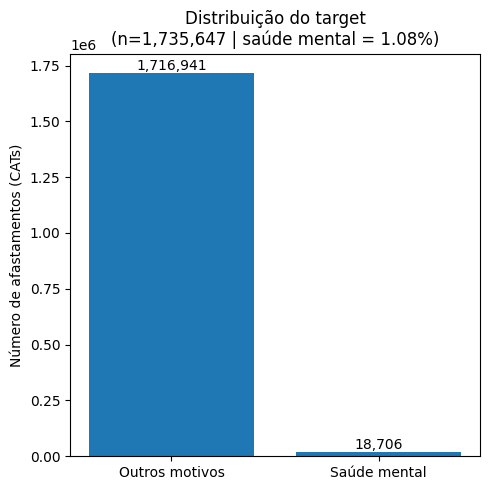

In [ ]:
# Gráfico simples da proporção
fig, ax = plt.subplots(figsize=(5, 5))
contagem = df['target_saude_mental'].value_counts().sort_index()
labels = ['Outros motivos', 'Saúde mental']

ax.bar(labels, contagem.values)
ax.set_ylabel('Número de afastamentos (CATs)')
ax.set_title(f'Distribuição do target\n(n={len(df):,} | saúde mental = {df["target_saude_mental"].mean()*100:.2f}%)')

for i, v in enumerate(contagem.values):
    ax.text(i, v + 15000, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### razão de risco por setor (CNAE)

In [ ]:
# gerando tabela
prevalencia_real = df['target_saude_mental'].mean()

def razao_risco(df, coluna, min_n=30):
    resultados = []
    for nome, grupo in df.groupby(coluna):
        n_casos = (grupo['target_saude_mental'] == 1).sum()
        if n_casos < min_n:
            continue
        n_total = len(grupo)
        prevalencia_grupo = n_casos / n_total
        resultados.append({
            'grupo': nome,
            'n_total': n_total,
            'n_casos': n_casos,
            'prevalencia': prevalencia_grupo,
            'razao_risco': prevalencia_grupo / prevalencia_real
        })
    return pd.DataFrame(resultados).sort_values('razao_risco', ascending=False)

risco_setor = razao_risco(df, 'cnae_setor_macro')
risco_setor

,grupo,n_total,n_casos,prevalencia,razao_risco
8,Servicos_Financeiros_E_Bancos,15414,7301,0.473660,43.948845
2,Correios_Logistica_E_Transporte,91817,1878,0.020454,1.897811
0,Administracao_Publica_E_Defesa,46104,773,0.016766,1.555684
3,Educacao,35553,548,0.015414,1.430160
7,Saude_E_Servicos_Sociais,29726,433,0.014566,1.351549
9,Teleatendimento_E_Servicos_Apoio,261856,1979,0.007558,0.701235
6,Outros_Servicos_E_Tecnologia,406692,3022,0.007431,0.689460
1,Comercio_Varejo_E_Atacado,282234,1422,0.005038,0.467488
4,Industria_Agro_E_Construcao,528636,1284,0.002429,0.225366
5,Nao_Informado,37615,66,0.001755,0.162803


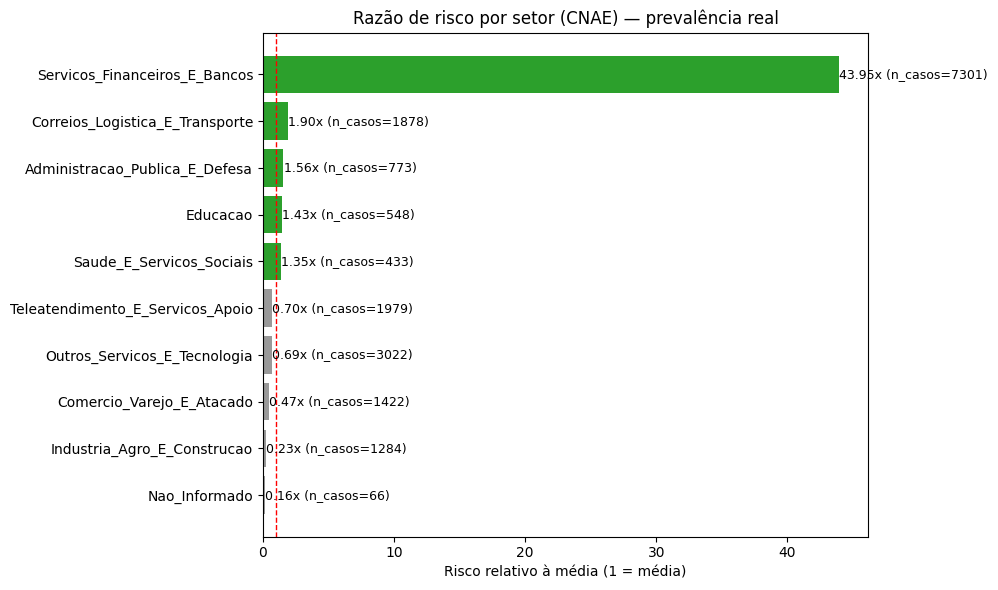

In [ ]:
# gráfico razão risco por setor
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#2ca02c' if r >= 1 else '#999999' for r in risco_setor['razao_risco']]

ax.barh(risco_setor['grupo'], risco_setor['razao_risco'], color=cores)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Risco relativo à média (1 = média)')
ax.set_title('Razão de risco por setor (CNAE) — prevalência real')

for i, (razao, n) in enumerate(zip(risco_setor['razao_risco'], risco_setor['n_casos'])):
    ax.text(razao + 0.02, i, f'{razao:.2f}x (n_casos={n})', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

- 47% de prevalência no setor financeiro é muito fora do padrão (43,9x a média)

- O claude AI encontrou 1.975 linhas duplicadas exatas só nesse setor, de 15.414 totais.

Vamos limpar linhas duplicadas e rodar novamente.

In [ ]:
print('Linhas duplicadas (exceto a 1ª ocorrência):', df.duplicated().sum())
print('Prevalência do target antes:', round(df['target_saude_mental'].mean() * 100, 3), '%')

df_sem_dup = df.drop_duplicates()

print('Prevalência do target depois:', round(df_sem_dup['target_saude_mental'].mean() * 100, 3), '%')

Linhas duplicadas (exceto a 1ª ocorrência): 196494
Prevalência do target antes: 1.078 %
Prevalência do target depois: 1.052 %


In [ ]:
prevalencia_real = df['target_saude_mental'].mean()

def razao_risco(df, coluna, min_n=30):
    resultados = []
    for nome, grupo in df.groupby(coluna):
        n_casos = (grupo['target_saude_mental'] == 1).sum()
        if n_casos < min_n:
            continue
        n_total = len(grupo)
        prevalencia_grupo = n_casos / n_total
        resultados.append({
            'grupo': nome,
            'n_total': n_total,
            'n_casos': n_casos,
            'prevalencia': prevalencia_grupo,
            'razao_risco': prevalencia_grupo / prevalencia_real
        })
    return pd.DataFrame(resultados).sort_values('razao_risco', ascending=False)

risco_setor = razao_risco(df, 'cnae_setor_macro')
risco_setor

,grupo,n_total,n_casos,prevalencia,razao_risco
8,Servicos_Financeiros_E_Bancos,15414,7301,0.473660,43.948845
2,Correios_Logistica_E_Transporte,91817,1878,0.020454,1.897811
0,Administracao_Publica_E_Defesa,46104,773,0.016766,1.555684
3,Educacao,35553,548,0.015414,1.430160
7,Saude_E_Servicos_Sociais,29726,433,0.014566,1.351549
9,Teleatendimento_E_Servicos_Apoio,261856,1979,0.007558,0.701235
6,Outros_Servicos_E_Tecnologia,406692,3022,0.007431,0.689460
1,Comercio_Varejo_E_Atacado,282234,1422,0.005038,0.467488
4,Industria_Agro_E_Construcao,528636,1284,0.002429,0.225366
5,Nao_Informado,37615,66,0.001755,0.162803


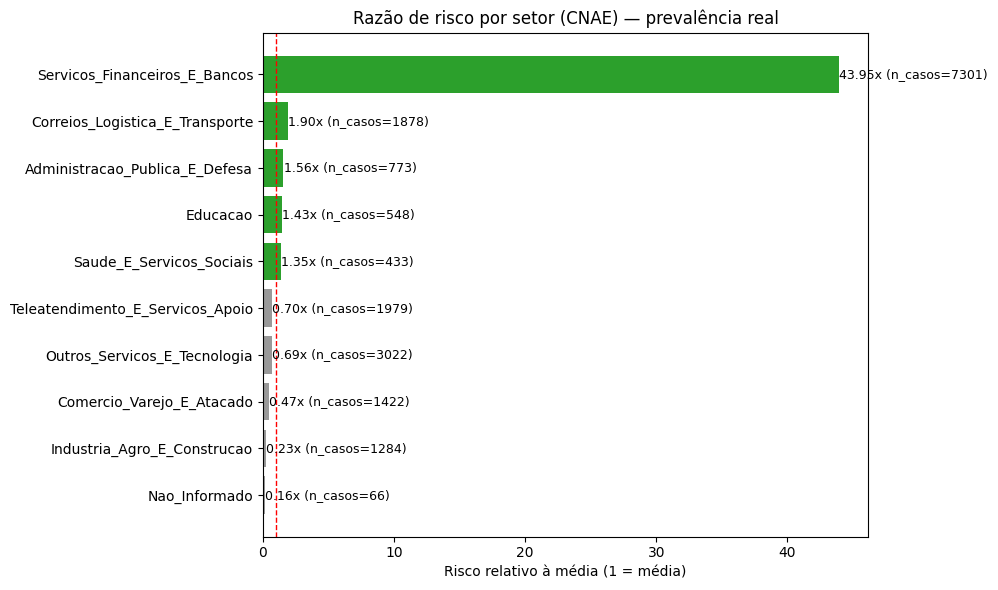

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#2ca02c' if r >= 1 else '#999999' for r in risco_setor['razao_risco']]

ax.barh(risco_setor['grupo'], risco_setor['razao_risco'], color=cores)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Risco relativo à média (1 = média)')
ax.set_title('Razão de risco por setor (CNAE) — prevalência real')

for i, (razao, n) in enumerate(zip(risco_setor['razao_risco'], risco_setor['n_casos'])):
    ax.text(razao + 0.02, i, f'{razao:.2f}x (n_casos={n})', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

O setor de Serviços Financeiros e Bancos concentra o maior risco relativo de afastamento por saúde mental: 47,4% dos registros do setor (7.301 de 15.414) são classificados como saúde mental, uma razão de risco de 43,9x em relação à média da base (1,08%) — muito acima dos demais setores.

Antes de tratar esse valor como achado válido, ele foi checado quanto a possíveis artefatos (mesma lógica aplicada à inconsistência geográfica do item A1): duplicatas exatas não explicam o resultado (a prevalência cai apenas de 47,4% para 46,9% ao removê-las).

Educação, Administração Pública e Saúde/Serviços Sociais também aparecem com risco acima da média (1,35x–1,55x), setores tradicionalmente associados a alta carga emocional e de atendimento ao público. Já Indústria (0,23x) e Comércio (0,47x) ficam abaixo da média — coerente com maior prevalência de acidentes físicos típicos nesses setores.

---



### Razão de risco por grupo ocupacional (CBO)

In [ ]:
risco_cbo = razao_risco(df, 'cbo_grupo_macro')
risco_cbo

,grupo,n_total,n_casos,prevalencia,razao_risco
2,Gestores_Diretores_Gerentes,22997,3264,0.141932,13.169201
6,Profissionais_Especialistas_Nivel_Superior,85883,5208,0.060641,5.626577
7,Servicos_Administrativos_Atendimento,197411,4709,0.023854,2.213287
8,Tecnicos_Nivel_Medio,231786,2096,0.009043,0.839044
1,Comercio_e_Servicos,415122,2040,0.004914,0.455969
5,Producao_Industrial_Artesanato,514851,1091,0.002119,0.196618
4,Operadores_Instalacoes_Maquinas,133502,176,0.001318,0.122322
3,Manutencao_E_Reparacao,75600,86,0.001138,0.105550
0,Agropecuaria_Forestal_Pesca,58395,34,0.000582,0.054024


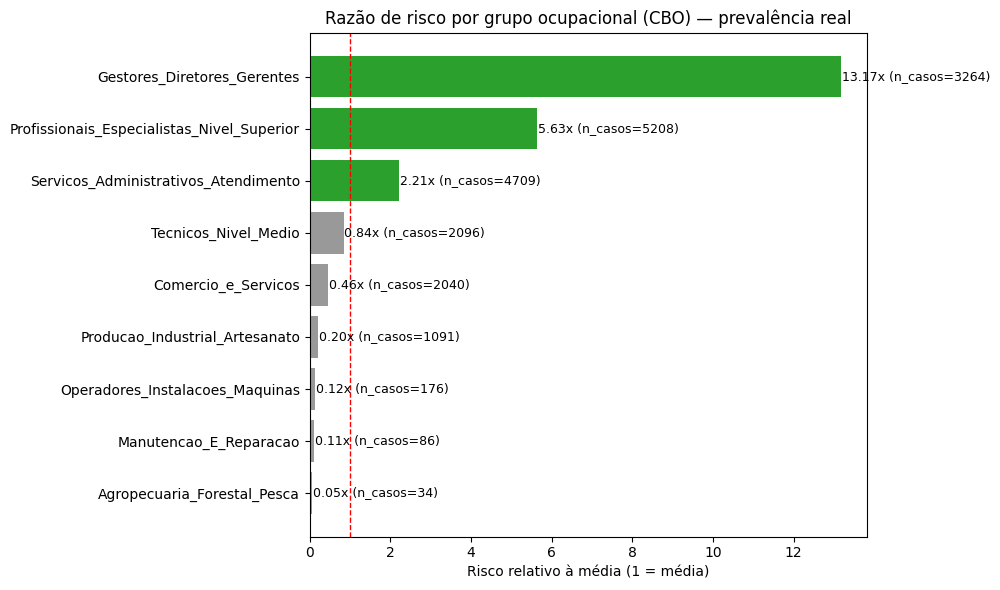

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
cores = ['#2ca02c' if r >= 1 else '#999999' for r in risco_cbo['razao_risco']]

ax.barh(risco_cbo['grupo'], risco_cbo['razao_risco'], color=cores)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Risco relativo à média (1 = média)')
ax.set_title('Razão de risco por grupo ocupacional (CBO) — prevalência real')

for i, (razao, n) in enumerate(zip(risco_cbo['razao_risco'], risco_cbo['n_casos'])):
    ax.text(razao + 0.02, i, f'{razao:.2f}x (n_casos={n})', va='center', fontsize=9)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

O risco de afastamento por saúde mental cresce de forma consistente com o nível de responsabilidade do cargo: Gestores/Diretores/Gerentes têm a maior razão de risco da base, 13,2x a média (14,2% dos 22.997 registros do grupo são saúde mental), seguidos por Profissionais Especialistas de Nível Superior (5,6x) e Serviços Administrativos/Atendimento (2,2x).

Esse padrão é coerente com a literatura sobre burnout, que associa maior carga de decisão, cobrança por resultados e exposição a atendimento/pressão constante a maior risco psicológico.

Do outro lado, ocupações operacionais e de produção têm risco bem abaixo da média: Produção Industrial (0,20x), Operadores de Máquinas (0,12x), Manutenção e Reparação (0,11x) e Agropecuária/Florestal/Pesca (0,05x, a menor razão da base).

---

### Gênero: Composição vs. Razão de Risco

In [ ]:
print('=== Distribuição geral por gênero (toda a base) ===')
print(df['genero'].value_counts())
print((df['genero'].value_counts(normalize=True) * 100).round(2))

=== Distribuição geral por gênero (toda a base) ===
genero
Masculino    1102106
Feminino      633541
Name: count, dtype: int64
genero
Masculino    63.5
Feminino     36.5
Name: proportion, dtype: float64


In [ ]:
print('=== Distribuição por gênero — apenas casos NÃO saúde mental (target=0) ===')
df_outros = df[df['target_saude_mental'] == 0]

print(df_outros['genero'].value_counts())
print((df_outros['genero'].value_counts(normalize=True) * 100).round(2))

=== Distribuição por gênero — apenas casos NÃO saúde mental (target=0) ===
genero
Masculino    1095065
Feminino      621876
Name: count, dtype: int64
genero
Masculino    63.78
Feminino     36.22
Name: proportion, dtype: float64


In [ ]:
print('=== Composição: % dos CASOS por gênero ===')
print(df[df['target_saude_mental']==1]['genero'].value_counts(normalize=True).round(3) * 100)

print()
print('=== Razão de risco de saude mental por gênero (prevalência dentro de cada grupo) ===')
risco_genero = razao_risco(df, 'genero')
risco_genero

=== Composição: % dos CASOS por gênero ===
genero
Feminino     62.4
Masculino    37.6
Name: proportion, dtype: float64

=== Razão de risco de saude mental por gênero (prevalência dentro de cada grupo) ===


,grupo,n_total,n_casos,prevalencia,razao_risco
0,Feminino,633541,11665,0.018412,1.708404
1,Masculino,1102106,7041,0.006389,0.592777


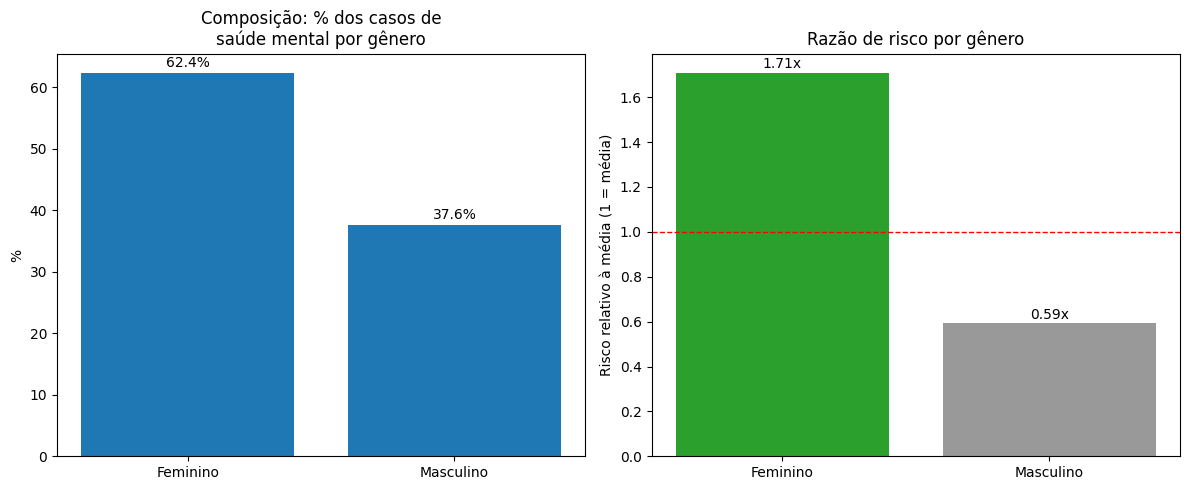

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: composição dos casos
composicao = df[df['target_saude_mental']==1]['genero'].value_counts(normalize=True) * 100
axes[0].bar(composicao.index, composicao.values, color='#1f77b4')
axes[0].set_title('Composição: % dos casos de\nsaúde mental por gênero')
axes[0].set_ylabel('%')
for i, v in enumerate(composicao.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center')

# Gráfico 2: razão de risco
cores = ['#2ca02c' if r >= 1 else '#999999' for r in risco_genero['razao_risco']]
axes[1].bar(risco_genero['grupo'], risco_genero['razao_risco'], color=cores)
axes[1].axhline(1, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Razão de risco por gênero')
axes[1].set_ylabel('Risco relativo à média (1 = média)')
for i, v in enumerate(risco_genero['razao_risco']):
    axes[1].text(i, v + 0.02, f'{v:.2f}x', ha='center')

plt.tight_layout()
plt.show()

In [ ]:
comparacao_genero = pd.DataFrame({
    'Base geral (%)': (df['genero'].value_counts(normalize=True) * 100).round(2),
    'Outros motivos (%)': (df[df['target_saude_mental']==0]['genero'].value_counts(normalize=True) * 100).round(2),
    'Saúde mental (%)': (df[df['target_saude_mental']==1]['genero'].value_counts(normalize=True) * 100).round(2),
})
comparacao_genero

,Base geral (%),Outros motivos (%),Saúde mental (%)
genero,,,
Feminino,36.5,36.22,62.36
Masculino,63.5,63.78,37.64


A base geral tem mais registros de homens (63,5%) do que mulheres (36,5%) — proporção que se mantém quase idêntica nos casos que não são saúde mental (63,78% homens). Porém, entre os casos de saúde mental, essa relação se inverte: 62,4% são mulheres, mesmo elas sendo minoria na base.

Calculando a prevalência dentro de cada grupo:
- Mulheres: 11.665 casos em 633.541 registros → prevalência de 1,84%
- Homens: 7.041 casos em 1.102.106 registros → prevalência de 0,64%

Isso resulta numa razão de risco de aproximadamente **1,71x** para mulheres e **0,59x** para homens — ou seja, controlando pelo tamanho de cada grupo, **mulheres têm cerca de 2,9x mais chance de ter um afastamento por saúde mental do que homens**.

Esse resultado confirma um dos três achados principais do TCC: o risco de afastamento por saúde mental é maior entre mulheres, e essa diferença só fica visível quando se compara a proporção dentro de cada grupo — a leitura pela composição bruta (**"mulheres são 36,5% da base, mas 62,4% dos casos"**) sozinha, sem essa normalização, já sugeriria uma direção parecida, mas subestimaria a magnitude real da disparidade.

---



### Idade: distribuição e faixas de risco

In [ ]:
bins = [0, 18, 29, 39, 49, 59, 120]
labels = ['Até 18 anos', '19-29 anos', '30-39 anos', '40-49 anos', '50-59 anos', '60+ anos']

df['faixa_etaria'] = pd.cut(df['idade'], bins=bins, labels=labels, right=True)

print('=== Faixa etária — base geral ===')
print(df['faixa_etaria'].value_counts().sort_index())
print((df['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2))

=== Faixa etária — base geral ===
faixa_etaria
Até 18 anos     18259
19-29 anos     572264
30-39 anos     471313
40-49 anos     393899
50-59 anos     217885
60+ anos        62024
Name: count, dtype: int64
faixa_etaria
Até 18 anos     1.05
19-29 anos     32.97
30-39 anos     27.15
40-49 anos     22.69
50-59 anos     12.55
60+ anos        3.57
Name: proportion, dtype: float64


In [ ]:
print('=== Faixa etária — target=0 (outros motivos) ===')
df_outros = df[df['target_saude_mental'] == 0]
print(df_outros['faixa_etaria'].value_counts().sort_index())
print((df_outros['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2))

=== Faixa etária — target=0 (outros motivos) ===
faixa_etaria
Até 18 anos     18244
19-29 anos     569678
30-39 anos     464342
40-49 anos     387556
50-59 anos     215429
60+ anos        61689
Name: count, dtype: int64
faixa_etaria
Até 18 anos     1.06
19-29 anos     33.18
30-39 anos     27.04
40-49 anos     22.57
50-59 anos     12.55
60+ anos        3.59
Name: proportion, dtype: float64


In [ ]:
print('=== Faixa etária — target=1 (saúde mental) ===')
df_sm = df[df['target_saude_mental'] == 1]
print(df_sm['faixa_etaria'].value_counts().sort_index())
print((df_sm['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2))

=== Faixa etária — target=1 (saúde mental) ===
faixa_etaria
Até 18 anos      15
19-29 anos     2586
30-39 anos     6971
40-49 anos     6343
50-59 anos     2456
60+ anos        335
Name: count, dtype: int64
faixa_etaria
Até 18 anos     0.08
19-29 anos     13.82
30-39 anos     37.27
40-49 anos     33.91
50-59 anos     13.13
60+ anos        1.79
Name: proportion, dtype: float64


In [ ]:
comparacao_idade = pd.DataFrame({
    'Base geral (%)': (df['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2),
    'Outros motivos (%)': (df_outros['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2),
    'Saúde mental (%)': (df_sm['faixa_etaria'].value_counts(normalize=True).sort_index() * 100).round(2),
})
comparacao_idade

,Base geral (%),Outros motivos (%),Saúde mental (%)
faixa_etaria,,,
Até 18 anos,1.05,1.06,0.08
19-29 anos,32.97,33.18,13.82
30-39 anos,27.15,27.04,37.27
40-49 anos,22.69,22.57,33.91
50-59 anos,12.55,12.55,13.13
60+ anos,3.57,3.59,1.79


A distribuição etária da base geral é bem próxima da distribuição dos casos não relacionados a saúde mental — ambas concentradas em 19-29 anos (~33%) e 30-39 anos (~27%). Mas nos casos de saúde mental, o centro de massa se desloca claramente para faixas mais maduras: 30-39 anos (37,3%) e 40-49 anos (33,9%) juntas somam mais de 71% dos casos, enquanto 19-29 anos cai de 33% (base geral) para apenas 13,8% dos casos.

O risco tem formato de "sino", com pico em 40-49 anos (1,49x), seguido de perto por 30-39 anos (1,37x) — a faixa de maior maturidade profissional e carreira consolidada.

Trabalhadores mais jovens (até 29 anos) e mais próximos da aposentadoria (60+) têm risco bem abaixo da média.

Esse padrão é coerente com o terceiro achado principal do TCC: **o risco concentra-se em cargos de liderança e ensino superior completo, perfis que tendem a se consolidar justamente nessa faixa etária de meia-carreira (30-49 anos).**


---

### Afastamentos por Saúde Mental por região

In [ ]:
# o próximo passo é Geografia, usando uf_confiavel
#(com a ressalva documentada — uf_acidente original fica de fora por ser inconsistente):

risco_uf = razao_risco(df, 'uf_confiavel')
risco_uf

,grupo,n_total,n_casos,prevalencia,razao_risco
4,DF,27577,984,0.035682,3.310766
13,PB,10185,257,0.025233,2.341276
17,RJ,115562,2500,0.021633,2.007268
18,RN,11294,233,0.020630,1.914206
14,PE,36100,623,0.017258,1.601258
0,AL,9898,164,0.016569,1.537365
2,BA,46807,737,0.015746,1.460956
15,PI,6510,87,0.013364,1.239992
23,SP,604339,7822,0.012943,1.200930
3,CE,36178,407,0.011250,1.043831


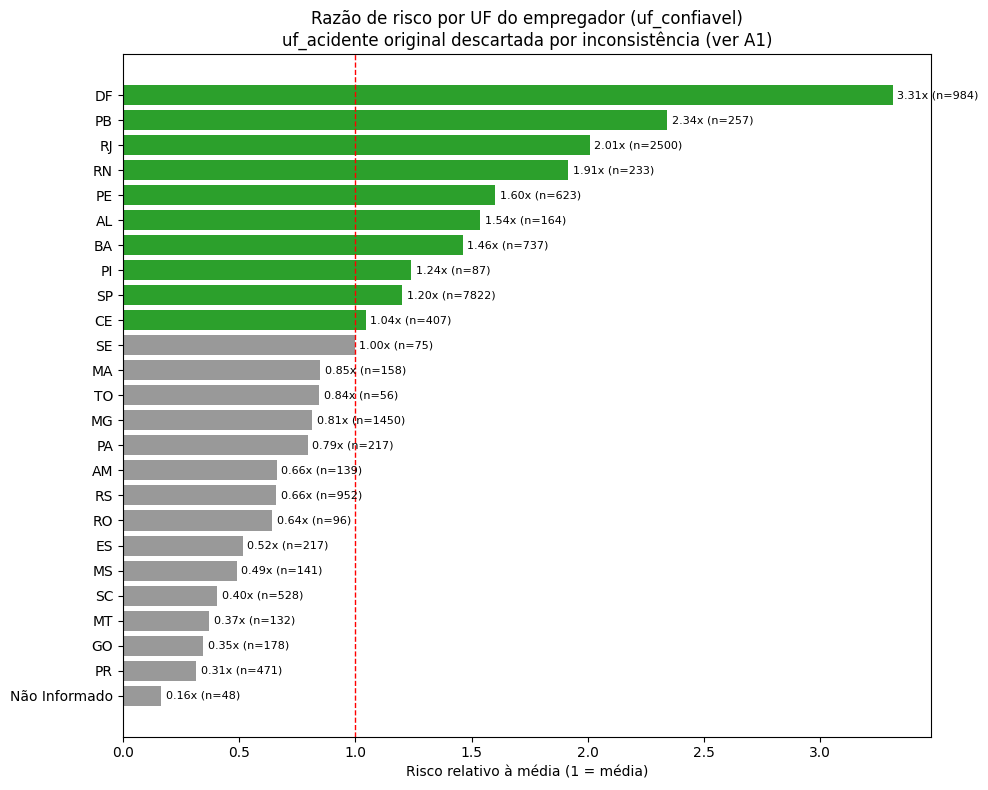

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
cores = ['#2ca02c' if r >= 1 else '#999999' for r in risco_uf['razao_risco']]

ax.barh(risco_uf['grupo'], risco_uf['razao_risco'], color=cores)
ax.axvline(1, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Risco relativo à média (1 = média)')
ax.set_title('Razão de risco por UF do empregador (uf_confiavel)\nuf_acidente original descartada por inconsistência (ver A1)')

for i, (razao, n) in enumerate(zip(risco_uf['razao_risco'], risco_uf['n_casos'])):
    ax.text(razao + 0.02, i, f'{razao:.2f}x (n={n})', va='center', fontsize=8)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Também vale ver a composição bruta (quantos casos absolutos por estado), já que a razão de risco sozinha pode esconder estados com poucos casos:

risco_uf[['grupo', 'n_total', 'n_casos', 'razao_risco']].sort_values('n_casos', ascending=False).head(10)

,grupo,n_total,n_casos,razao_risco
23,SP,604339,7822,1.200930
17,RJ,115562,2500,2.007268
8,MG,165361,1450,0.813608
4,DF,27577,984,3.310766
20,RS,133749,952,0.660430
2,BA,46807,737,1.460956
14,PE,36100,623,1.601258
21,SC,120976,528,0.404963
16,PR,138825,471,0.314799
3,CE,36178,407,1.043831


A distribuição geográfica separa bem duas leituras diferentes, assim como aconteceu com gênero: volume absoluto de casos e risco relativo contam histórias distintas.

Em número absoluto de casos, o ranking é dominado pelos estados com maior volume de empregadores — SP (7.822 casos), RJ (2.500) e MG (1.450) — o que é esperado, já que são os estados com mais CATs registradas no total (SP sozinho tem 604 mil registros, mais de um terço da base). Isso reflete tamanho da economia/população ocupada, não necessariamente risco.

Já pela razão de risco (prevalência do estado ÷ prevalência geral de 1,08%), o ranking muda bastante: DF lidera com 3,31x a média, seguido por PB (2,34x), RJ (2,01x), RN (1,91x) e PE (1,60x) — nenhum desses (exceto RJ) aparece entre os líderes em volume absoluto.

O caso do DF é coerente com o achado de setor/ocupação: forte concentração de Administração Pública e cargos de nível superior, ambos já identificados como grupos de maior risco. SP, apesar do volume, tem razão de risco moderada (1,20x) — próxima da média nacional, apesar de concentrar o maior número absoluto de casos.

No extremo oposto, PR (0,31x), GO (0,35x) e SC (0,40x) têm risco bem abaixo da média, mesmo com volumes consideráveis de CATs no total.

Nota metodológica: essa análise usa `uf_confiavel` (derivada de `uf_empregador`), e não `uf_acidente`, devido à inconsistência sistemática identificada nessa última coluna (ver seção sobre A1/qualidade dos dados).

---


### Evolução Temporal

- com cuidado especial porque 2026 está parcial (só até junho)

In [ ]:
df['ano'] = df['data_acidente'].dt.year
df['mes'] = df['data_acidente'].dt.month

evolucao_anual = df.groupby('ano').agg(
    n_total=('target_saude_mental', 'size'),
    n_casos=('target_saude_mental', 'sum')
)
evolucao_anual['prevalencia'] = evolucao_anual['n_casos'] / evolucao_anual['n_total'] * 100

# meses disponíveis por ano, pra não comparar 12 meses com 6
meses_por_ano = df.groupby('ano')['mes'].nunique()
evolucao_anual['meses_disponiveis'] = meses_por_ano
evolucao_anual['casos_por_mes'] = evolucao_anual['n_casos'] / evolucao_anual['meses_disponiveis']

evolucao_anual

,n_total,n_casos,prevalencia,meses_disponiveis,casos_por_mes
ano,,,,,
2023,377685,3394,0.898632,12,282.833333
2024,509021,4245,0.833954,12,353.750000
2025,578588,7563,1.307148,12,630.250000
2026,270353,3504,1.296083,6,584.000000


In [ ]:
df['ano'] = df['data_acidente'].dt.year
df['semestre'] = df['data_acidente'].dt.month.apply(lambda m: 1 if m <= 6 else 2)
df['periodo'] = df['ano'].astype(str) + '-S' + df['semestre'].astype(str)

evolucao_semestral = df.groupby('periodo').agg(
    n_total=('target_saude_mental', 'size'),
    n_saude_mental=('target_saude_mental', 'sum'),
).reset_index()

evolucao_semestral['n_outros'] = evolucao_semestral['n_total'] - evolucao_semestral['n_saude_mental']
evolucao_semestral['prevalencia_saude_mental'] = evolucao_semestral['n_saude_mental'] / evolucao_semestral['n_total'] * 100
evolucao_semestral['prevalencia_outros'] = evolucao_semestral['n_outros'] / evolucao_semestral['n_total'] * 100

evolucao_semestral = evolucao_semestral.sort_values('periodo').reset_index(drop=True)
evolucao_semestral

,periodo,n_total,n_saude_mental,n_outros,prevalencia_saude_mental,prevalencia_outros
0,2023-S1,67312,1258,66054,1.868909,98.131091
1,2023-S2,310373,2136,308237,0.688204,99.311796
2,2024-S1,393606,3574,390032,0.908015,99.091985
3,2024-S2,115415,671,114744,0.581380,99.418620
4,2025-S1,174548,3081,171467,1.765131,98.234869
5,2025-S2,404040,4482,399558,1.109296,98.890704
6,2026-S1,270353,3504,266849,1.296083,98.703917


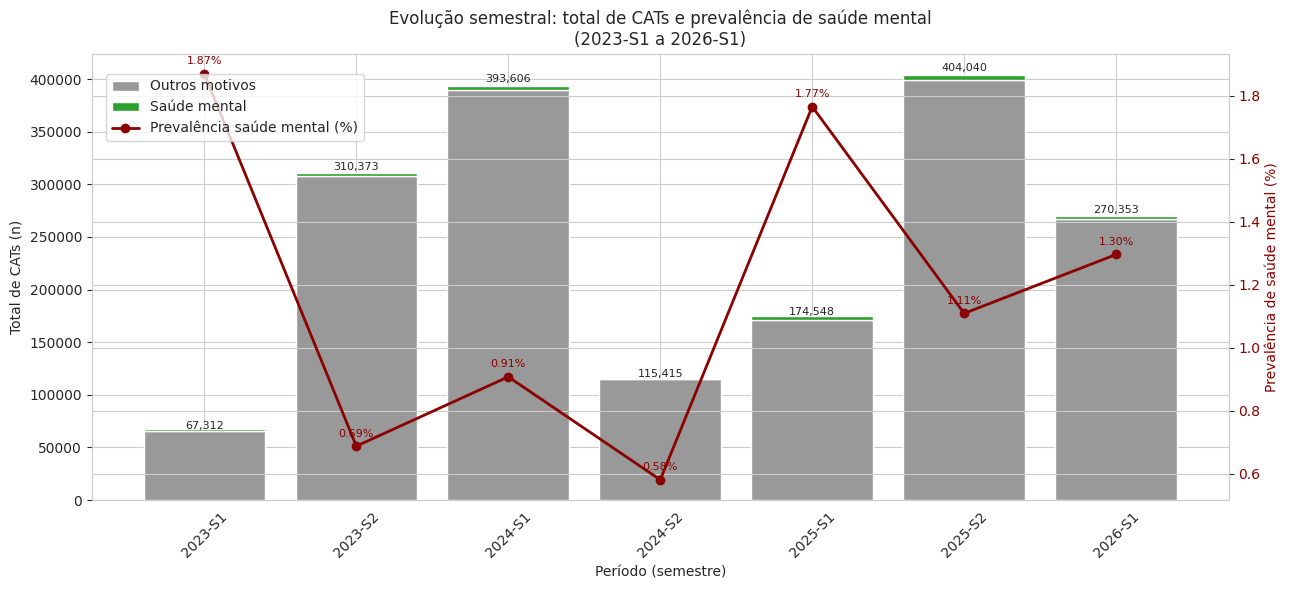

In [ ]:
fig, ax1 = plt.subplots(figsize=(13, 6))

x = evolucao_semestral['periodo']

# Barras empilhadas: total de casos por período
ax1.bar(x, evolucao_semestral['n_outros'], color='#999999', label='Outros motivos')
ax1.bar(x, evolucao_semestral['n_saude_mental'], bottom=evolucao_semestral['n_outros'],
        color='#2ca02c', label='Saúde mental')
ax1.set_ylabel('Total de CATs (n)')
ax1.set_xlabel('Período (semestre)')
plt.xticks(rotation=45)

# Rótulo do total no topo de cada barra
for i, total in enumerate(evolucao_semestral['n_total']):
    ax1.text(i, total + total*0.01, f'{total:,}', ha='center', fontsize=8)

# Linha de prevalência de saúde mental no eixo secundário
ax2 = ax1.twinx()
ax2.plot(x, evolucao_semestral['prevalencia_saude_mental'], color='darkred',
         marker='o', linewidth=2, label='Prevalência saúde mental (%)')
ax2.set_ylabel('Prevalência de saúde mental (%)', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

for i, prev in enumerate(evolucao_semestral['prevalencia_saude_mental']):
    ax2.text(i, prev + 0.03, f'{prev:.2f}%', ha='center', fontsize=8, color='darkred')

ax1.set_title('Evolução semestral: total de CATs e prevalência de saúde mental\n(2023-S1 a 2026-S1)')
fig.legend(loc='upper left', bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.show()

# Cruzamentos

*   Heatmap CBO × Setor
*   Gênero × Faixa etária
*   Gênero × Setor ou CBO × Faixa etária


In [ ]:
import seaborn as sns

def razao_risco_2d(df, col1, col2, min_n=30):
    prevalencia_real = df['target_saude_mental'].mean()

    tabela_casos = df.pivot_table(
        index=col1, columns=col2, values='target_saude_mental',
        aggfunc='sum', fill_value=0
    )
    tabela_total = df.pivot_table(
        index=col1, columns=col2, values='target_saude_mental',
        aggfunc='size', fill_value=0
    )

    tabela_prevalencia = tabela_casos / tabela_total
    tabela_razao = tabela_prevalencia / prevalencia_real

    # células com n_casos abaixo do mínimo viram NaN (não aparecem no heatmap)
    tabela_razao = tabela_razao.where(tabela_casos >= min_n)

    return tabela_razao, tabela_casos

### 1. Heatmap CBO × Setor

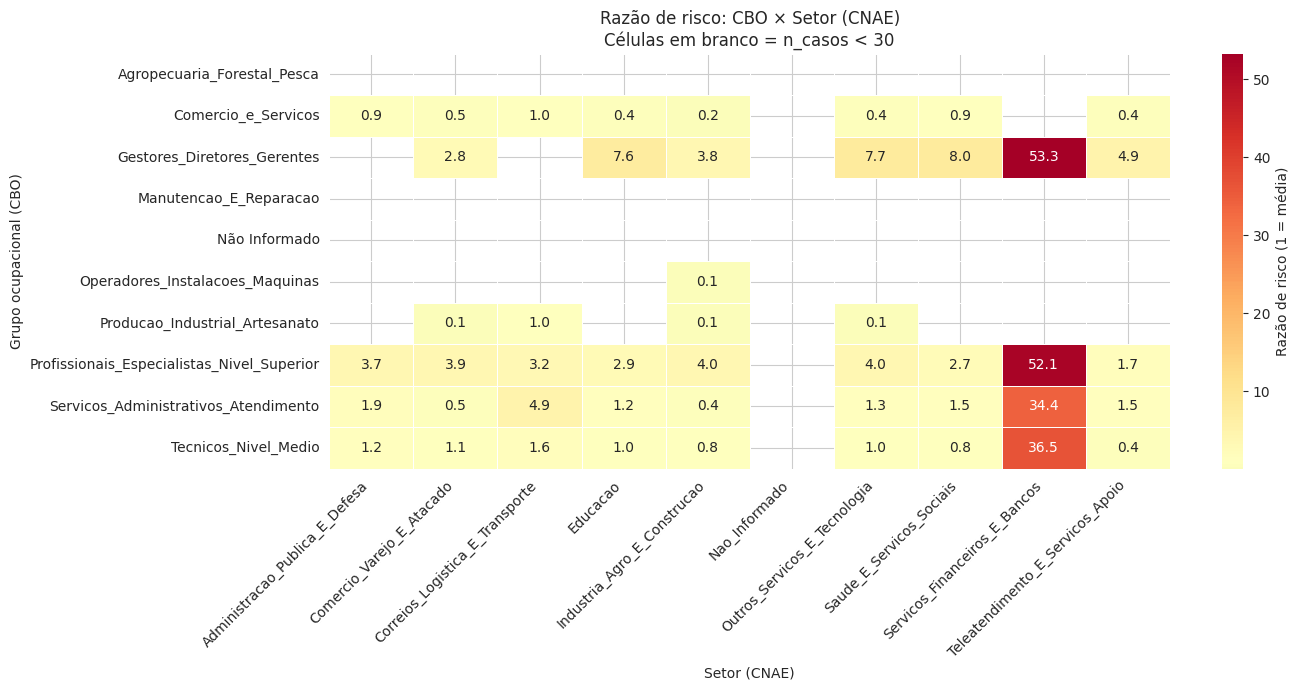

In [ ]:
razao_cbo_setor, n_casos_cbo_setor = razao_risco_2d(df, 'cbo_grupo_macro', 'cnae_setor_macro')

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(razao_cbo_setor, annot=True, fmt='.1f', cmap='RdYlGn_r', center=1,
            cbar_kws={'label': 'Razão de risco (1 = média)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Razão de risco: CBO × Setor (CNAE)\nCélulas em branco = n_casos < 30')
ax.set_xlabel('Setor (CNAE)')
ax.set_ylabel('Grupo ocupacional (CBO)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 2. Gênero × Faixa etária

/tmp/ipykernel_765/3462383145.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_casos = df.pivot_table(
/tmp/ipykernel_765/3462383145.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  tabela_total = df.pivot_table(


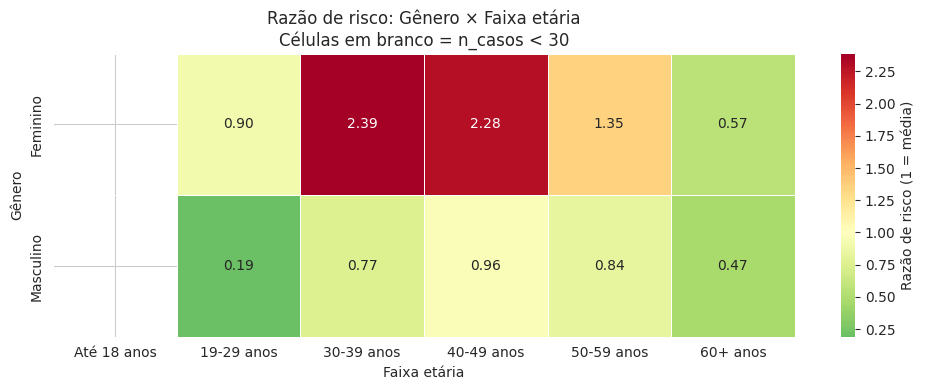

In [ ]:
razao_genero_idade, n_casos_genero_idade = razao_risco_2d(df, 'genero', 'faixa_etaria')

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(razao_genero_idade, annot=True, fmt='.2f', cmap='RdYlGn_r', center=1,
            cbar_kws={'label': 'Razão de risco (1 = média)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Razão de risco: Gênero × Faixa etária\nCélulas em branco = n_casos < 30')
ax.set_xlabel('Faixa etária')
ax.set_ylabel('Gênero')
plt.tight_layout()
plt.show()

### 3. Gênero × Setor

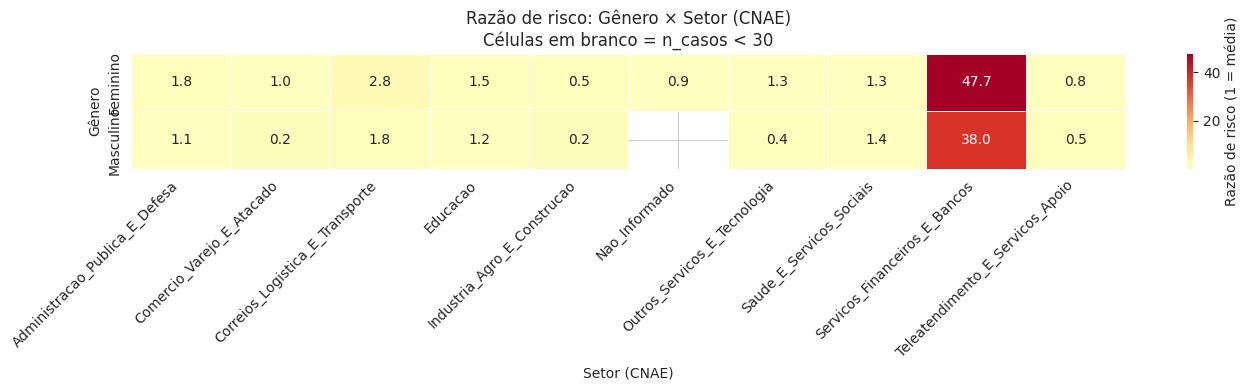

In [ ]:
razao_genero_setor, n_casos_genero_setor = razao_risco_2d(df, 'genero', 'cnae_setor_macro')

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(razao_genero_setor, annot=True, fmt='.1f', cmap='RdYlGn_r', center=1,
            cbar_kws={'label': 'Razão de risco (1 = média)'}, ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('Razão de risco: Gênero × Setor (CNAE)\nCélulas em branco = n_casos < 30')
ax.set_xlabel('Setor (CNAE)')
ax.set_ylabel('Gênero')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
##Salvando em PARQUET pois ele preserva a tipagem e é mais leve
df.to_parquet('pos_EDA_df_geral.parquet', index=False)

print("\n Base higienizada e salva com sucesso em 'pos_EDA_df_geral.parquet'!")


 Base higienizada e salva com sucesso em 'pos_EDA_df_geral.parquet'!
